# Clustering

Here we will use the PCA space you generated before and cluster it using the algorithms you saw in the lecture.

Like always, we need to install/load some packages:

In [25]:
import pandas as pd
import numpy as np
from sklearn.cluster import AgglomerativeClustering
from sklearn.cluster import KMeans
from sklearn.cluster import DBSCAN
import matplotlib.pyplot as plt

And we need to import our data:

In [5]:
df = pd.read_csv("pca_reduced_features.csv", index_col=0)
df.head()

,HOMO-LUMO gap,HOMO,LUMO,Dipole module,Global SASA,G solv. in H2O,G of H-bonds H2O,Electrophil. idx,Nucleophilicity idx,Second IP,MolLogP,PC1,PC2,PC3,PC4
code_name,,,,,,,,,,,,,,,
Anion_0001,5.3351,-4.2024,1.1327,7.1380,192.5967,-68.9658,-2.1547,0.4616,4166.6667,11.1108,-1.2438,0.053490,-3.420270,0.862894,-0.029575
Anion_0002,4.0571,-10.3812,-6.3242,1.8413,600.8035,-9.6848,-5.2430,0.5261,1.5797,10.8525,6.1085,-5.924067,5.053182,4.923166,-4.142888
Anion_0003,5.3131,-4.3573,0.9559,37.5426,598.9517,-70.5050,-2.3100,0.3239,1843.3891,7.9764,4.2176,2.978071,2.856800,3.262246,2.208219
Anion_0004,5.2403,-4.5644,0.6759,27.8235,610.9026,-69.4885,-1.8624,0.3234,1522.5735,7.7882,4.9978,2.624023,2.590203,3.374438,1.686337
Anion_0005,4.0262,-10.3534,-6.3272,1.8364,568.8514,-10.4796,-5.9490,0.5978,1.4856,11.0191,5.4944,-6.271307,4.951125,4.705275,-4.497058


Lets make an array with our PCA coordinates in.

In [7]:
X = np.array(df[["PC1", "PC2", "PC3", "PC4"]])

Let's cluster the dataset, choose the number of clusters you want by changing the value of `k` below.

In [9]:
k = 3
kmeans = KMeans(n_clusters=k, random_state=0, init='random', n_init=10, tol=1e-4)

y_kmeans = kmeans.fit_predict(X)

Now let's plot the PCs but coloring by cluster

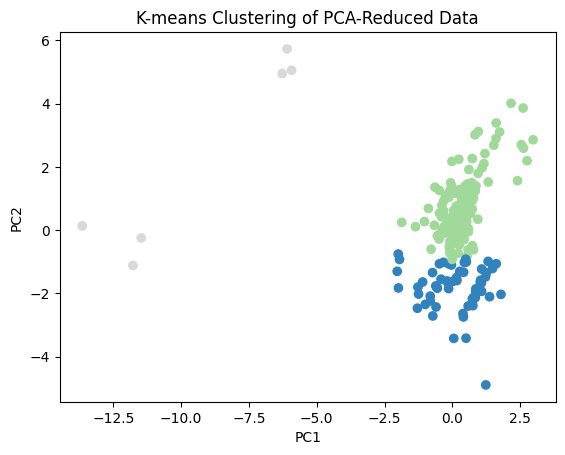

In [21]:
dim1 = df["PC1"]
dim2 = df["PC2"]
plt.scatter(dim1, dim2, c=y_kmeans, cmap='tab20c')
plt.xlabel(dim1.name)
plt.ylabel(dim2.name)
plt.title("K-means Clustering of PCA-Reduced Data")
plt.show()

Next, we can have a look at hierarchical clustering

In [ ]:
ac = AgglomerativeClustering(n_clusters=3, metric='euclidean', linkage='complete', compute_distances=True)

ac2 = AgglomerativeClustering(distance_threshold=0, n_clusters=None, metric='euclidean', linkage='complete')

labels = ac.fit(X)

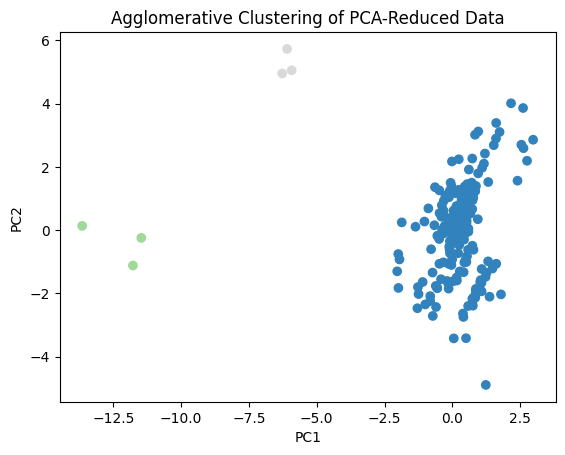

In [24]:
dim1 = df["PC1"]
dim2 = df["PC2"]
plt.scatter(dim1, dim2, c=labels.labels_, cmap='tab20c')
plt.xlabel(dim1.name)
plt.ylabel(dim2.name)
plt.title("Agglomerative Clustering of PCA-Reduced Data")
plt.show()

And finally, we can have a look at density-based clustering

In [26]:
db = DBSCAN(eps=1, min_samples=5, metric='euclidean')
labels = db.fit_predict(X)

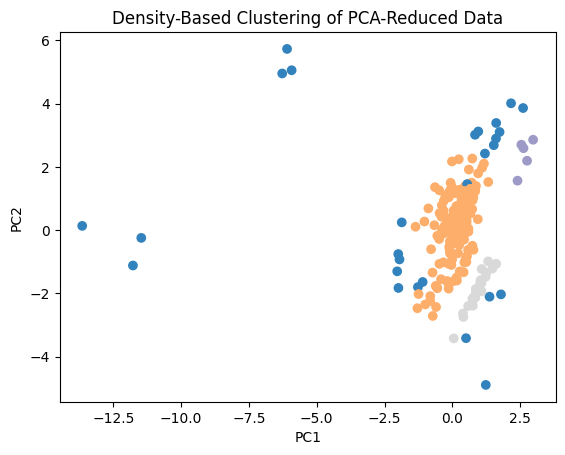

In [28]:
dim1 = df["PC1"]
dim2 = df["PC2"]
plt.scatter(dim1, dim2, c=labels, cmap='tab20c')
plt.xlabel(dim1.name)
plt.ylabel(dim2.name)
plt.title("Density-Based Clustering of PCA-Reduced Data")
plt.show()

*Compare and contrast each clustering method with your dataset*